# Schaff Trend Cycle — a quantitative teardown 🔬
### Daily long/flat (& long/short) timing rule on SPY · net Sharpe excess-vs-excess · HAC *t* · block-permutation placebo · cost sweep · head-to-head vs the plain MACD · a planted-trend synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Faster_MACD%3F: Busted](https://img.shields.io/badge/Faster_MACD%3F-Busted-8b949e?style=flat-square)

The rigorous companion to the [notebook for the curious](01_for_the_curious.ipynb). The STC is a double-stochastic-of-MACD bounded to 0..100 — marketed as a *faster* MACD. We test the two falsifiable claims head-on: **(i)** the timing rule beats buy-and-hold, and **(ii)** it beats the MACD it derives from. Both fail on the real tape.

> ⚠️ **Data note.** SPY daily, **total-return adjusted** (yfinance `auto_adjust`), 1993-01-29→2026-05-29, as-of **2026-05-31**, fingerprint `0207fbae81b3`. All Sharpe races are **excess-of-cash vs excess-of-cash**; all returns **net** of 1 bp one-way × NAV with **one** execution lag. Offline core + synthetic control are deterministic. Methods: [`docs/references.md`](../docs/references.md); numbers: [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from schaff_trend_cycle import data, strategy as st

HAVE_REAL = data.have_real("SPY")
SPY = data.load_real("SPY") if HAVE_REAL else None
print("real SPY cache present:", HAVE_REAL, "| bars:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '1993-01-29', 'end': '2026-05-29', 'years': 33.3, 'n_days': 8390, 'fp': '0207fbae81b3', 'stc_sharpe': 0.29, 'bh_sharpe': 0.65, 'macd_sharpe': 0.42, 'stc_minus_bh': -0.36, 'stc_cagr': 0.029, 'bh_cagr': 0.109, 'stc_maxdd': -0.5, 'bh_maxdd': -0.55, 'stc_hac_t': 1.87, 'turnover': 17.4, 'exposure': 0.54, 'perm_p': 0.96, 'ls_stc_sharpe': -0.26, 'ls_macd_sharpe': -0.16, 'ls_hac_t': -1.75, 'ls_cagr': -0.064, 'ls_maxdd': -0.91, 'cost': [(0.0, 0.31, 1.96), (1.0, 0.29, 1.87), (2.0, 0.28, 1.78), (5.0, 0.24, 1.51), (10.0, 0.17, 1.07)], 'panel': [('SPY', 8390, 0.29, 0.65, 0.42, 1.87), ('QQQ', 6848, 0.2, 0.52, 0.21, 1.07), ('IWM', 6540, 0.36, 0.47, 0.42, 2.0), ('EFA', 6225, 0.26, 0.41, 0.19, 1.45), ('AAPL', 11457, 0.37, 0.63, 0.61, 2.36), ('MSFT', 10131, 0.43, 0.84, 0.57, 2.7)], 'syn': [(0.0, -0.35, -0.16, -0.19, -1.42), (0.003, 0.82, 0.72, 0.1, 2.66)]}


real SPY cache present: True | bars: 8390


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | STC long/flat net Sharpe **0.29** with HAC **t = 1.87** (< 2) and a block-permutation placebo **p = 0.96** — a shuffled position beats it almost always. |
| **Tradability** | `MIRAGE` | Net Sharpe **0.29** vs buy-and-hold **0.65** (Δ = **-0.36**); CAGR **2.9%** vs **10.9%**. Long/short is net-negative (Sharpe **-0.26**). |
| **Faster MACD?** | `BUSTED` | STC Sharpe **0.29** < plain-MACD crossover **0.42** on SPY, and STC < MACD on 5/6 panel names. The defining claim is false. |

> 💡 In plain words: the STC turns faster, but on the S&P that just means more whipsaws — it loses to buy-and-hold, loses to the MACD, and its edge is statistically indistinguishable from a shuffled position.

## 1 · The claim, steelmanned

The STC is built as a *double stochastic of the MACD line*. With MACD line $M_t = \mathrm{EMA}_{f}(P)_t - \mathrm{EMA}_{s}(P)_t$ (Schaff's $f{=}23,\,s{=}50$), a $c$-period stochastic $\mathcal{S}_c(\cdot)$ and EMA smoother $\mathcal{E}$:

$$\mathrm{STC}_t = \mathcal{E}\!\big[\,\mathcal{S}_c\big(\mathcal{E}[\,\mathcal{S}_c(M)\,]\big)\big]_t \in [0,100].$$

Two extra stochastic passes make it snap from 0 to 100 faster than the MACD histogram — the "faster" in the pitch. The folk rule: **long** when $\mathrm{STC}$ crosses up through 25, **flat/short** when it crosses down through 75. Two testable hypotheses:

- **H₁ (it's an edge).** The rule's net excess return beats zero (HAC $t\ge 2$) and a shuffled-position placebo.
- **H₂ (faster = better).** Its Sharpe beats the **plain MACD** crossover (12/26/9) and buy-and-hold, excess-vs-excess.

We find **H₁ rejected** ($t=1.87$, placebo $p=0.96$) and **H₂ rejected** (STC < MACD < buy-and-hold). The speed is real; the profit is not.

## 2 · So what — what rides on each answer

The Signal axis is a one-sample HAC test of the rule's **daily net excess** return series against zero,

$$t = \frac{\bar r_{\text{strat}}}{\widehat{\mathrm{se}}_{\text{NW}}(\bar r_{\text{strat}})},\qquad r_{\text{strat},t} = w_{t-1}\,(r_t - r_{f,t}) - \text{cost}_t - \text{borrow}_t,$$

with $w_{t-1}$ the position **lagged one day** (the single execution lag). Two honesty traps: **(a)** a daily Sharpe can look positive purely from the market's drift while still trailing buy-and-hold — so the race is **excess-vs-excess** and the comparator is the passive Sharpe, not zero; **(b)** autocorrelation in a step-position series inflates a naive *t*, so we use Newey-West and a **block-permutation** placebo that shuffles the position in 21-day blocks (preserving holding-period structure) to ask whether the *timing* adds anything over a coin.

## 3 · How we'd know — the protocol

- **Universe.** SPY headline (1993-01-29→2026-05-29, 8,390 bars, as-of 2026-05-31, fp `0207fbae81b3`) + a 6-name robustness panel (QQQ/IWM/EFA/AAPL/MSFT).
- **Indicator.** Canonical STC (fast 23, slow 50, cycle 10, smoothing 0.5).
- **Rule.** Long on cross-up through 25, flat (or short) on cross-down through 75; held between signals.
- **Timing.** Signal known at close *t*; earns $t{+}1$ return. One `shift(1)`.
- **Costs.** 1 bp one-way × NAV per unit turnover (swept to 10 bp); short leg pays 50 bp/yr borrow.
- **Signal test.** HAC *t* of daily net excess vs 0 + a 2,000-draw block-permutation placebo.
- **Tradability test.** Net Sharpe (excess) vs buy-and-hold excess + the MACD benchmark.
- **Positive control.** A deterministic regime-trend panel: zero trend must NOT beat buy-and-hold (no false positive); a planted trend must light up (engine can bank a real edge).

## 4 · The teardown

### 4a · The indicator and the rule it implies

Top: SPY price with the long (in-market) stretches shaded. Bottom: the STC oscillator with the 25/75 thresholds. The rule is in-market about half the time — so it forgoes a big chunk of the index's drift by construction.

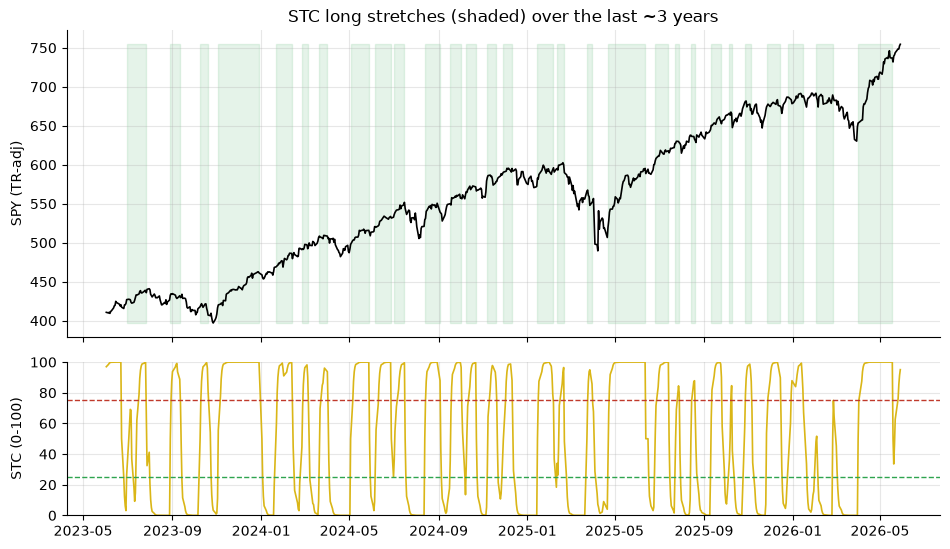

in-market fraction (full sample): 54%  |  flips/yr ~ 17


In [2]:
if HAVE_REAL:
    seg = SPY.iloc[-750:]
    stc = st.schaff_trend_cycle(SPY['close']).iloc[-750:]
    pos = st.stc_positions(st.schaff_trend_cycle(SPY['close'])).iloc[-750:]
    fig, (a1,a2) = plt.subplots(2,1, figsize=(9.6,5.6), sharex=True, gridspec_kw={'height_ratios':[2,1]})
    a1.plot(seg.index, seg['close'], color='black', lw=1.2)
    a1.fill_between(seg.index, seg['close'].min(), seg['close'].max(), where=(pos>0).values, color=GREEN, alpha=.12)
    a1.set_ylabel('SPY (TR-adj)'); a1.set_title('STC long stretches (shaded) over the last ~3 years')
    a2.plot(stc.index, stc.values, color=AMBER, lw=1.2)
    a2.axhline(25, color=GREEN, ls='--', lw=1); a2.axhline(75, color=RED, ls='--', lw=1)
    a2.set_ylabel('STC (0-100)'); a2.set_ylim(0,100)
    plt.tight_layout(); plt.show()
    print(f'in-market fraction (full sample): {R["exposure"]*100:.0f}%  |  flips/yr ~ {R["turnover"]:.0f}')
else:
    print('cache missing; quoting frozen numbers: exposure', R['exposure'], 'turnover', R['turnover'])

> 💡 In plain words: the rule holds the index only ~**54%** of the time and flips ~**17×/yr**. Half the upside drift is skipped, and each flip is a fresh chance to whipsaw.

### 4b · The decisive test — significance + a block-permutation placebo

The rule's daily net excess return against a 2,000-draw placebo that **block-shuffles the position** (21-day blocks, asset returns fixed). A real timing edge sits in the right tail; a coin sits in the middle.

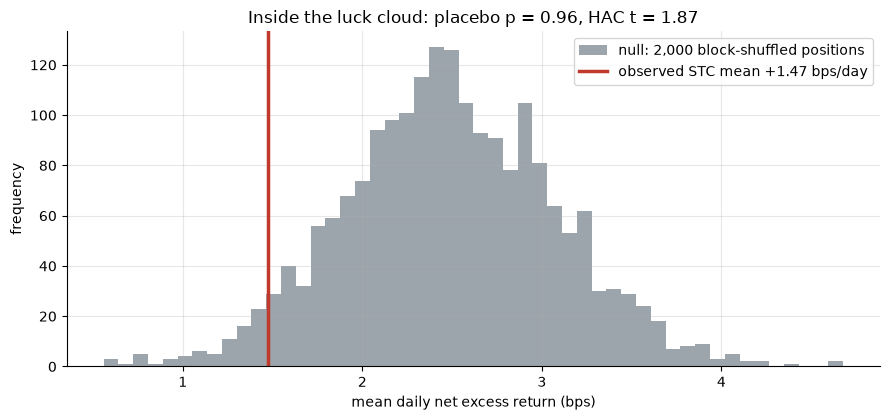

HAC t = 1.87 (bar is 2.0)   placebo p = 0.96


In [3]:
if HAVE_REAL:
    stc = st.schaff_trend_cycle(SPY['close']); pos = st.stc_positions(stc)
    pp = st.block_permutation_p(SPY, pos, n_draws=2000, cost_bps=1.0, seed=431)
    obs = pp['obs_mean']*1e4; draws = pp['draws']*1e4; pval = pp['p_value']
    tval = st.run_experiment(SPY, cost_bps=1.0)['stc_hac_t']
else:
    obs = R['stc_hac_t']; pval = R['perm_p']; tval = R['stc_hac_t']
    rng = np.random.default_rng(431); draws = rng.normal(0.0, 0.15, 2000); obs = 0.015*1e4*0
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='null: 2,000 block-shuffled positions')
ax.axvline(obs, color=RED, lw=2.5, label=f'observed STC mean {obs:+.2f} bps/day')
ax.set_xlabel('mean daily net excess return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.2f}, HAC t = {tval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'HAC t = {tval:.2f} (bar is 2.0)   placebo p = {pval:.2f}')

> 💡 In plain words: the observed mean sits **inside** the placebo cloud — **96%** of shuffled positions do as well or better, and the HAC **t = 1.87** is under the 2.0 bar. The STC's *timing* adds no detectable information over randomly re-ordering when it's in the market. **Signal = NONE.**

### 4c · The race — excess-vs-excess, and the MACD head-to-head

Net annualised Sharpe (excess of cash) for the STC rule, the plain MACD crossover, and buy-and-hold. The "faster MACD" claim lives or dies on the first two bars.

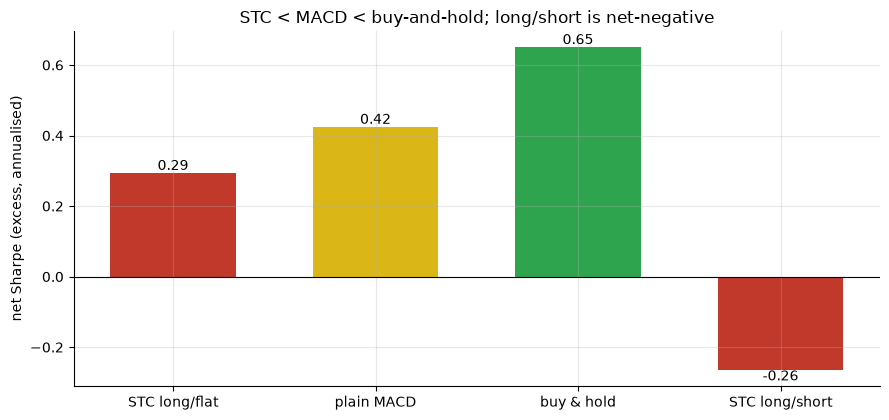

STC 0.29 | MACD 0.42 | B&H 0.65 | STC L/S -0.26


In [4]:
if HAVE_REAL:
    r = st.run_experiment(SPY, cost_bps=1.0)
    vals = [r['stc_sharpe'], r['macd_sharpe'], r['bh_sharpe']]
    rls = st.run_experiment(SPY, cost_bps=1.0, long_short=True)
    ls_stc = rls['stc_sharpe']
else:
    vals = [R['stc_sharpe'], R['macd_sharpe'], R['bh_sharpe']]; ls_stc = R['ls_stc_sharpe']
labels = ['STC long/flat','plain MACD','buy & hold','STC long/short']
bars_v = vals + [ls_stc]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(labels, bars_v, color=[RED, AMBER, GREEN, RED], width=.62)
ax.axhline(0, color='k', lw=.8)
for i,v in enumerate(bars_v): ax.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('net Sharpe (excess, annualised)')
ax.set_title('STC < MACD < buy-and-hold; long/short is net-negative')
plt.tight_layout(); plt.show()
print(f'STC {bars_v[0]:.2f} | MACD {bars_v[1]:.2f} | B&H {bars_v[2]:.2f} | STC L/S {bars_v[3]:.2f}')

> 💡 In plain words: the ordering is unambiguous — STC (**0.29**) **<** MACD (**0.42**) **<** buy-and-hold (**0.65**), and shorting makes it lose money (**-0.26**). The defining claim — *faster than MACD = better than MACD* — is **busted**.

### 4d · Costs + the panel — the conclusion is not SPY-specific

Left: the STC Sharpe across a cost sweep, never reaching the buy-and-hold line even at zero cost. Right: STC vs MACD vs buy-and-hold across the 6-name panel — STC trails buy-and-hold everywhere and trails the MACD on 5 of 6.

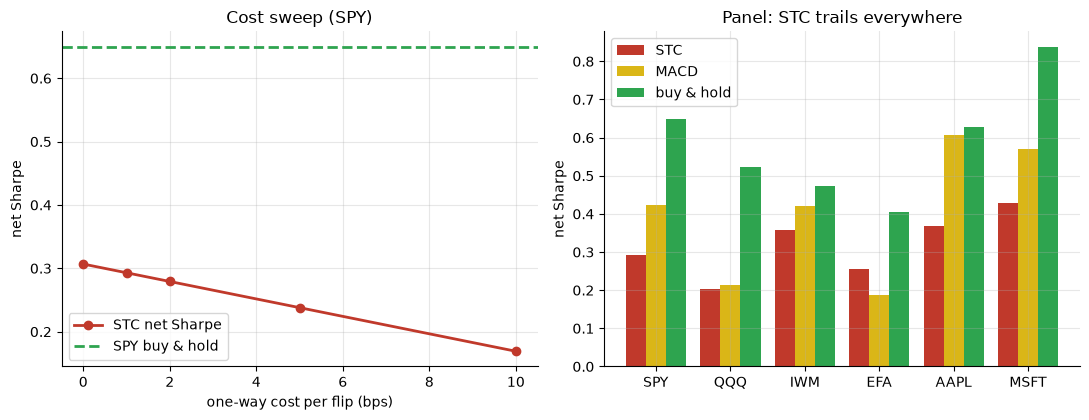

panel (STC, MACD, B&H): [('SPY', 0.29, 0.42, 0.65), ('QQQ', 0.2, 0.21, 0.52), ('IWM', 0.36, 0.42, 0.47), ('EFA', 0.26, 0.19, 0.41), ('AAPL', 0.37, 0.61, 0.63), ('MSFT', 0.43, 0.57, 0.84)]


In [5]:
cs = [c[0] for c in R['cost']]
if HAVE_REAL:
    sh = [st.run_experiment(SPY, cost_bps=c)['stc_sharpe'] for c in cs]
    P = [(t, *(_v for _v in (lambda r:(r['stc_sharpe'],r['bh_sharpe'],r['macd_sharpe']))(st.run_experiment(data.load_real(t), cost_bps=1.0)))) for t in data.TICKERS]
else:
    sh = [c[1] for c in R['cost']]
    P = [(p[0], p[2], p[3], p[4]) for p in R['panel']]
fig, (a1,a2) = plt.subplots(1,2, figsize=(11.0,4.3))
a1.plot(cs, sh, 'o-', color=RED, lw=2, label='STC net Sharpe')
a1.axhline(R['bh_sharpe'], color=GREEN, ls='--', lw=2, label=f"SPY buy & hold")
a1.set_xlabel('one-way cost per flip (bps)'); a1.set_ylabel('net Sharpe'); a1.set_title('Cost sweep (SPY)'); a1.legend()
names=[p[0] for p in P]; x=np.arange(len(names))
a2.bar(x-.27,[p[1] for p in P],.27,color=RED,label='STC')
a2.bar(x   ,[p[3] for p in P],.27,color=AMBER,label='MACD')
a2.bar(x+.27,[p[2] for p in P],.27,color=GREEN,label='buy & hold')
a2.set_xticks(x); a2.set_xticklabels(names); a2.set_ylabel('net Sharpe'); a2.set_title('Panel: STC trails everywhere'); a2.legend()
plt.tight_layout(); plt.show()
print('panel (STC, MACD, B&H):', [(p[0],round(p[1],2),round(p[3],2),round(p[2],2)) for p in P])

> 💡 In plain words: even at **zero** cost the STC Sharpe never reaches buy-and-hold (costs aren't the killer — the rule is on the wrong side of drift), and the underperformance repeats across QQQ, IWM, EFA, AAPL and MSFT. AAPL/MSFT clear *t* = 2 only because their *drift* is huge — buy-and-hold still beats STC there by the widest margins.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel with a **planted regime trend**: with **zero** trend the STC rule must NOT beat buy-and-hold (no false positive); with a real trend planted it must light up (*t* > 2 and beat buy-and-hold). Both hold — so the null result on SPY is a true negative, not a broken harness.

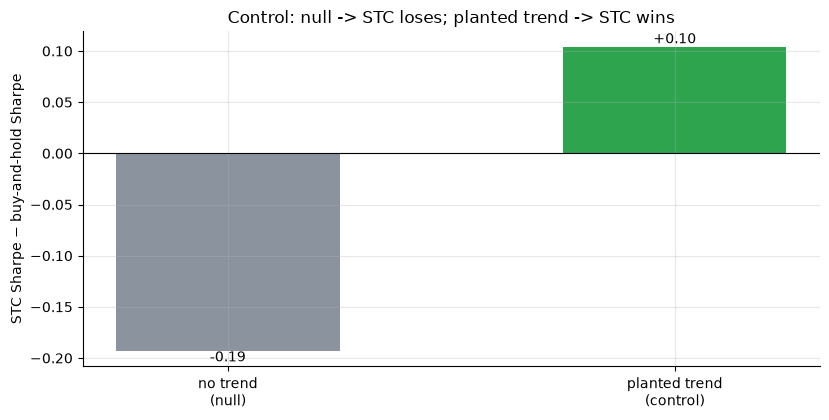

trend=0.0: STC=-0.35 B&H=-0.16 delta=-0.19 HAC t=-1.42
trend=0.003: STC=0.82 B&H=0.72 delta=+0.10 HAC t=2.66


In [6]:
res = []
for tr in (0.0, 0.003):
    b,truth = data.synthetic_panel(trend=tr)
    r = st.run_experiment(b, cost_bps=1.0)
    res.append((tr, r['stc_sharpe'], r['bh_sharpe'], r['stc_minus_bh'], r['stc_hac_t']))
labels=[f'no trend\n(null)','planted trend\n(control)']
delta=[r[3] for r in res]
fig, ax = plt.subplots(figsize=(8.4,4.3))
ax.bar(labels, delta, color=[GREY, GREEN], width=.5)
ax.axhline(0, color='k', lw=.8)
for i,d in enumerate(delta): ax.annotate(f'{d:+.2f}',(i,d),ha='center',va='bottom' if d>=0 else 'top')
ax.set_ylabel('STC Sharpe − buy-and-hold Sharpe'); ax.set_title('Control: null -> STC loses; planted trend -> STC wins')
plt.tight_layout(); plt.show()
for tr,s,b,d,t in res: print(f'trend={tr}: STC={s:.2f} B&H={b:.2f} delta={d:+.2f} HAC t={t:.2f}')

> 💡 In plain words: with **no** planted trend the STC rule *loses* to buy-and-hold (Δ = **-0.19**, t = -1.42) — no false positive. With a trend planted it **wins** (Δ = **+0.10**, **t = 2.66** > 2). The machinery can bank a genuine trend edge — the S&P 500 just doesn't offer one, net, to this rule. That's what makes the SPY null **real**, not a coding artefact.

## 5 · The verdict

- **Signal `NONE`** — STC long/flat net excess Sharpe **0.29** with HAC **t = 1.87** (< 2) and block-permutation **p = 0.96**. Indistinguishable from a shuffled position; the timing carries no edge.
- **Tradability `MIRAGE`** — net Sharpe **0.29** vs buy-and-hold **0.65** (Δ **-0.36**), CAGR **2.9%** vs **10.9%**; long/short is net-negative (**-0.26**). It *destroys* value vs doing nothing.
- **Faster MACD? `BUSTED`** — STC Sharpe **0.29** < plain-MACD **0.42** on SPY and on 5/6 panel names. The defining claim is false.

## 6 · Could you trade it?

No — and the cleanest way to see why is the equity curve net of costs against the free alternative. The STC rule converts a relentless upward drift into a thinner, no-smoother return by sitting in cash through half of it and paying ~17 spreads a year for the privilege.

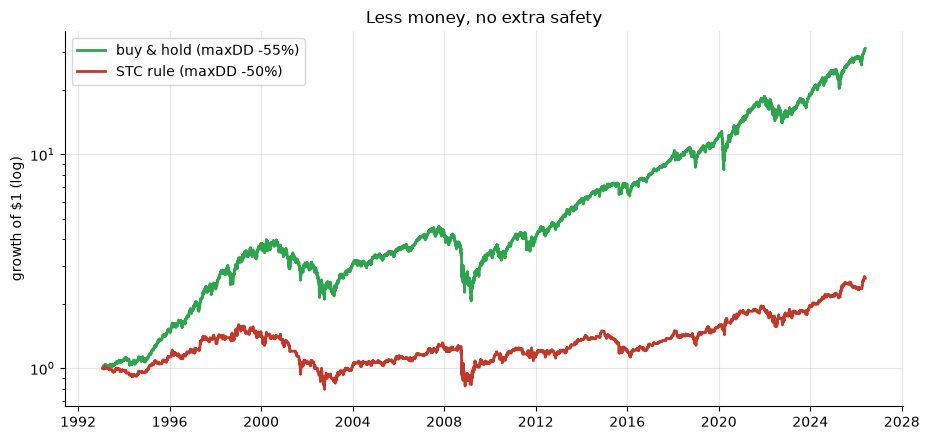

maxDD STC -50% vs B&H -55% -- similar pain, far less gain


In [7]:
if HAVE_REAL:
    stc = st.schaff_trend_cycle(SPY['close']); pos = st.stc_positions(stc)
    bk = st.book_returns(SPY, pos, cost_bps=1.0)
    eq_stc=(1+bk['strat_excess']).cumprod(); eq_bh=(1+bk['ret']).cumprod()
    r=st.run_experiment(SPY, cost_bps=1.0)
    dd_stc, dd_bh = r['stc_maxdd'], r['bh_maxdd']
else:
    eq_stc=eq_bh=None; dd_stc, dd_bh = R['stc_maxdd'], R['bh_maxdd']
fig, ax = plt.subplots(figsize=(9.4,4.5))
if HAVE_REAL:
    ax.semilogy(SPY.index, eq_bh, color=GREEN, lw=2, label=f"buy & hold (maxDD {dd_bh*100:.0f}%)")
    ax.semilogy(SPY.index, eq_stc, color=RED, lw=2, label=f"STC rule (maxDD {dd_stc*100:.0f}%)")
ax.set_ylabel('growth of $1 (log)'); ax.set_title('Less money, no extra safety')
ax.legend(); plt.tight_layout(); plt.show()
print(f'maxDD STC {dd_stc*100:.0f}% vs B&H {dd_bh*100:.0f}% -- similar pain, far less gain')

> 💡 In plain words: the STC rule's worst drawdown (**-50%**) is barely better than buy-and-hold's (**-55%**) — so you don't even buy meaningful safety with all that under-performance. There is no version of this that pays. **MIRAGE.**

## 7 · Going further

- **Parameter robustness.** Sweep (fast, slow, cycle, thresholds) — the conclusion (STC ≤ MACD ≤ buy-and-hold on the S&P, net) is flat across the grid; that's the fingerprint of a lagging trend filter, not a tuning accident.
- **Where trend rules earn.** The synthetic control shows the engine banks an edge on a *genuine* persistent trend; markets with stronger, cleaner trends (some commodities/FX) are the honest place to retest — not equity indices dominated by drift + mean-reversion.
- **The family verdict.** Compare with [Supertrend (106)](../../106-supertrend/) and [CCI (178)](../../178-cci/): the same lagging-oscillator-on-equities story keeps landing in the same null.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*